Saving household_energy_consumption.csv to household_energy_consumption (2).csv

First 5 rows:
  Household_ID        Date  Energy_Consumption_kWh  Household_Size  \
0       H00001  2025-04-01                     8.4               4   
1       H00001  2025-04-02                     7.9               4   
2       H00001  2025-04-03                     9.2               4   
3       H00001  2025-04-04                     7.9               4   
4       H00001  2025-04-05                     9.6               4   

   Avg_Temperature_C Has_AC  Peak_Hours_Usage_kWh  
0               17.8     No                   3.2  
1               17.3     No                   2.8  
2               18.6     No                   3.0  
3               18.2     No                   2.7  
4               11.9     No                   3.2  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtyp

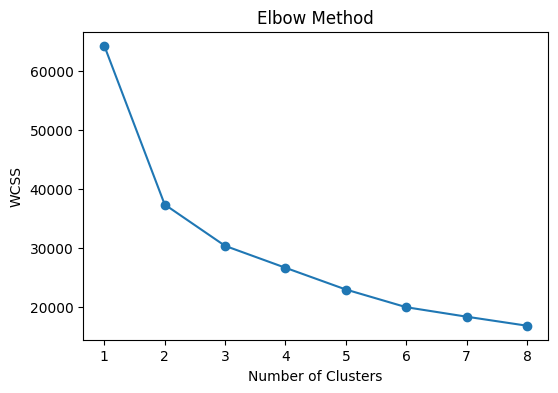


Cluster Distribution:
cluster
1    5419
2    4897
0    2541
Name: count, dtype: int64

 Random Forest Performance
RMSE: 0.7154755034117426
MAE: 0.5247818004584921
R2 Score: 0.9831909406676467

 Gradient Boosting Performance
RMSE: 0.6456499851975878
MAE: 0.48448684918321
R2 Score: 0.9863117426028858


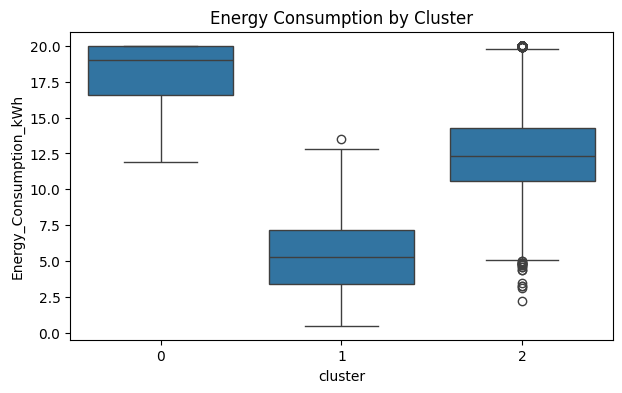


 Random Forest WITHOUT Clustering Performance
RMSE: 0.7243591686315273
MAE: 0.5297963925500426
R2 Score: 0.9827709315835

Future Energy Consumption Prediction
Random Forest: 10.55666666666667
Gradient Boosting: 9.247264150322327


In [2]:
# ENERGY CONSUMPTION FORECASTING WITH PATTERN DISCOVERY


# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



# 2. UPLOAD DATASET (FOR GOOGLE COLAB)


from google.colab import files
uploaded = files.upload()



# 3. LOAD DATASET


df = pd.read_csv("household_energy_consumption.csv")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())



# 4. DATA PREPROCESSING


# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create time related features
df["day"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek

# Encode categorical column Has_AC
le = LabelEncoder()
df["Has_AC"] = le.fit_transform(df["Has_AC"])



# 5. FEATURE EXTRACTION FOR CLUSTERING


# Aggregate household behavior
household_features = df.groupby("Household_ID").agg(

    avg_consumption = ("Energy_Consumption_kWh","mean"),

    consumption_variance = ("Energy_Consumption_kWh","var"),

    peak_usage = ("Peak_Hours_Usage_kWh","mean"),

    avg_temperature = ("Avg_Temperature_C","mean"),

    household_size = ("Household_Size","mean")

).reset_index()

print("\nHousehold Feature Sample:")
print(household_features.head())



# 6. STANDARDIZE FEATURES


scaler = StandardScaler()

cluster_features = scaler.fit_transform(
    household_features.drop("Household_ID", axis=1)
)



# 7. ELBOW METHOD TO FIND OPTIMAL CLUSTERS


wcss = []

for i in range(1,9):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(cluster_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(range(1,9), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()



# 8. APPLY K-MEANS CLUSTERING


kmeans = KMeans(n_clusters=3, random_state=42)

household_features["cluster"] = kmeans.fit_predict(cluster_features)

print("\nCluster Distribution:")
print(household_features["cluster"].value_counts())



# 9. MERGE CLUSTER LABELS BACK TO ORIGINAL DATASET


df = df.merge(

    household_features[["Household_ID","cluster"]],

    on="Household_ID",

    how="left"
)



# 10. PREPARE DATA FOR SUPERVISED LEARNING


features = [

    "Household_Size",

    "Avg_Temperature_C",

    "Has_AC",

    "Peak_Hours_Usage_kWh",

    "day",

    "month",

    "day_of_week",

    "cluster"
]

target = "Energy_Consumption_kWh"

X = df[features]

y = df[target]



# 11. TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)



# 12. RANDOM FOREST REGRESSOR


rf_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)



# 13. GRADIENT BOOSTING REGRESSOR


gb_model = GradientBoostingRegressor(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)



# 14. MODEL EVALUATION


def evaluate_model(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    print("\n",model_name,"Performance")

    print("RMSE:",rmse)

    print("MAE:",mae)

    print("R2 Score:",r2)


evaluate_model(y_test, rf_predictions, "Random Forest")

evaluate_model(y_test, gb_predictions, "Gradient Boosting")



# 15. VISUALIZE ENERGY PATTERNS BY CLUSTER


plt.figure(figsize=(7,4))

sns.boxplot(

    x="cluster",

    y="Energy_Consumption_kWh",

    data=df
)

plt.title("Energy Consumption by Cluster")

plt.show()



# 16. MODEL WITHOUT CLUSTER (COMPARISON)


features_no_cluster = [

    "Household_Size",

    "Avg_Temperature_C",

    "Has_AC",

    "Peak_Hours_Usage_kWh",

    "day",

    "month",

    "day_of_week"
]

X_nc = df[features_no_cluster]

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(

    X_nc,

    y,

    test_size=0.2,

    random_state=42
)

rf_nc = RandomForestRegressor(random_state=42)

rf_nc.fit(X_train_nc, y_train_nc)

pred_nc = rf_nc.predict(X_test_nc)

evaluate_model(y_test_nc, pred_nc, "Random Forest WITHOUT Clustering")



# 17. FUTURE ENERGY PREDICTION


future_sample = pd.DataFrame({

    "Household_Size":[4],

    "Avg_Temperature_C":[25],

    "Has_AC":[1],

    "Peak_Hours_Usage_kWh":[3.5],

    "day":[15],

    "month":[7],

    "day_of_week":[2],

    "cluster":[1]
})

rf_future = rf_model.predict(future_sample)

gb_future = gb_model.predict(future_sample)

print("\nFuture Energy Consumption Prediction")

print("Random Forest:", rf_future[0])

print("Gradient Boosting:", gb_future[0])